# Credit Risk Independent Project - Modelling Default Risk

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

## Information about features of UCI dataset

<details>
<summary><strong> Features overview (click to expand)</strong></summary>
<p style="font-size:18px;"><u>There are 25 variables in total with the following descriptions:</u></p>

ID: ID of each client

LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

SEX: Gender (1=male, 2=female)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)

AGE: Age in years

PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

PAY_2: Repayment status in August, 2005 (scale same as above)

PAY_3: Repayment status in July, 2005 (scale same as above)

PAY_4: Repayment status in June, 2005 (scale same as above)

PAY_5: Repayment status in May, 2005 (scale same as above)

PAY_6: Repayment status in April, 2005 (scale same as above)

BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

default.payment.next.month: Default payment (1=yes, 0=no)

</details>

## 0. Preprocessing and data cleaning

In [5]:
# Data cleaning

credit_default = pd.read_excel(
    "default of credit card clients.xls",
    header=1
)

default_outcome = credit_default["default payment next month"]
default = np.where(default_outcome == 1)
default = pd.DataFrame(default)
proportion_default = default.shape[1]/len(default_outcome) * 100

credit_default = credit_default.rename(columns={"LIMIT_BAL": "Credit Limit (NT Dollars)"})
credit_default = credit_default.rename(columns={"PAY_0": "Repayment Status (Sep 2005)"})
credit_default = credit_default.rename(columns={"PAY_2": "Repayment Status (Aug 2005)"})
credit_default = credit_default.rename(columns={"PAY_3": "Repayment Status (July 2005)"})
credit_default = credit_default.rename(columns={"PAY_4": "Repayment Status (June 2005)"})
credit_default = credit_default.rename(columns={"PAY_5": "Repayment Status (May 2005)"})
credit_default = credit_default.rename(columns={"PAY_6": "Repayment Status (April 2005)"})
credit_default = credit_default.rename(columns={"BILL_AMT1": "Amount of bill statement, NT Dollars (Sept 2005)"})
credit_default = credit_default.rename(columns={"BILL_AMT2": "Amount of bill statement, NT Dollars (Aug 2005)"})
credit_default = credit_default.rename(columns={"BILL_AMT3": "Amount of bill statement, NT Dollars (July 2005)"})
credit_default = credit_default.rename(columns={"BILL_AMT4": "Amount of bill statement, NT Dollars (June 2005)"})
credit_default = credit_default.rename(columns={"BILL_AMT5": "Amount of bill statement, NT Dollars (May 2005)"})
credit_default = credit_default.rename(columns={"BILL_AMT6": "Amount of bill statement, NT Dollars (April 2005)"})
credit_default = credit_default.rename(columns={"PAY_AMT1": " Amount of previous payment, NT Dollars (Sept 2005)"})
credit_default = credit_default.rename(columns={"PAY_AMT2": " Amount of previous payment, NT Dollars (Aug 2005)"})
credit_default = credit_default.rename(columns={"PAY_AMT3": " Amount of previous payment, NT Dollars (July 2005)"})
credit_default = credit_default.rename(columns={"PAY_AMT4": " Amount of previous payment, NT Dollars (June 2005)"})
credit_default = credit_default.rename(columns={"PAY_AMT5": " Amount of previous payment, NT Dollars (May 2005)"})
credit_default = credit_default.rename(columns={"PAY_AMT6": " Amount of previous payment, NT Dollars (April 2005)"})

# Convert categorical variables to binary (dummies)
credit_default = pd.get_dummies(credit_default, columns=['MARRIAGE', 'EDUCATION']).astype(int)
credit_default['SEX'] = credit_default['SEX'].map({1: 0, 2: 1})
repayment_cols = [col for col in credit_default.columns if "Repayment Status" in col]
credit_default[repayment_cols] = credit_default[repayment_cols].replace({-2:0, 0:0, -1:0})
credit_default = credit_default.drop(["ID"], axis = 1)
# Categories 5 and 6 both represent unknown education status and hence do not provide further information
credit_default = credit_default.drop(["EDUCATION_5", "EDUCATION_6"], axis = 1)
bill_cols = [
    'Amount of bill statement, NT Dollars (Sept 2005)',
    'Amount of bill statement, NT Dollars (Aug 2005)',
    'Amount of bill statement, NT Dollars (July 2005)',
    'Amount of bill statement, NT Dollars (June 2005)',
    'Amount of bill statement, NT Dollars (May 2005)',
    'Amount of bill statement, NT Dollars (April 2005)',
]

credit_default['bill_amt_mean'] = credit_default[bill_cols].mean(axis=1)
credit_default['bill_amt_change'] = (
    credit_default['Amount of bill statement, NT Dollars (Sept 2005)']
    - credit_default['Amount of bill statement, NT Dollars (April 2005)']
)
credit_default = credit_default.drop(columns=bill_cols)
credit_default

,Credit Limit (NT Dollars),SEX,AGE,Repayment Status (Sep 2005),Repayment Status (Aug 2005),Repayment Status (July 2005),Repayment Status (June 2005),Repayment Status (May 2005),Repayment Status (April 2005),"Amount of previous payment, NT Dollars (Sept 2005)",...,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,bill_amt_mean,bill_amt_change
0,20000,1,24,2,2,0,0,0,0,0,...,1,0,0,0,0,1,0,0,1284.000000,3913
1,120000,1,26,0,2,0,0,0,2,0,...,0,1,0,0,0,1,0,0,2846.166667,-579
2,90000,1,34,0,0,0,0,0,0,1518,...,0,1,0,0,0,1,0,0,16942.166667,13690
3,50000,1,37,0,0,0,0,0,0,2000,...,1,0,0,0,0,1,0,0,38555.666667,17443
4,50000,0,57,0,0,0,0,0,0,2000,...,1,0,0,0,0,1,0,0,18223.166667,-10514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,0,39,0,0,0,0,0,0,8500,...,1,0,0,0,0,0,1,0,120891.500000,172968
29996,150000,0,43,0,0,0,0,0,0,1837,...,0,1,0,0,0,0,1,0,3530.333333,1683
29997,30000,0,37,4,3,2,0,0,0,0,...,0,1,0,0,0,1,0,0,11749.333333,-15792
29998,80000,0,41,1,0,0,0,0,0,85900,...,1,0,0,0,0,0,1,0,44435.166667,-50589


## 1. Limitation of OLS for binary outcome (limitations of linear probability model, LPM)

A linear regression model works on pairs of ${{x_i,y_i}_{i=1}^{n}}$ with a design matrix $X$ containing $d$ features $X_i \in \mathbb{R}^d$, and a binary target variable (outcome) of customer defaulting on their loan of $y \in \set{0,1}$. 
The simplest (and most naive) approach to estimating $P(y=1|X)$ is to use a linear regression model such as $h_\theta(x) = \langle w, x \rangle + b$ with parameters $\theta = \langle w, b \rangle$ where $w$ is a vector of weights and $b$ is a scalar bias.

When this linear probability model (LPM) is used to estimate binary (or discrete) outcomes, estimating the probability the customer defaults on their loan of $P(y=1|X)$ with $\langle \theta, x_i\rangle$ that has an unbounded range yields estimates for the probability outside of the range of $\set{0,1}$ which are self-evidently nonsensical. Additionally, a binary target also does not have an error process that follows a Gaussian distribution with constant variance (homoskedasticity) that simple OLS makes assumption of. The LPM does not give accurate estimates for probability of discrete outcomes. 

## 2. Baseline (linear) Logit Model - Linear decision boundary

Suppose $z := w'X + b$ (an affine function). The sigmoid function $\sigma(z)$ in logistic regression (Logit) is defined as: $$\sigma(z) = \frac{1}{1 + e^{-z}}$$ which yields an S-shaped curve with probability estimates of $P(y=1|X)$ strictly bounded in $\mathbb{R} \to (0,1)$. 

The odds ratio is defined as $$O(z)= \frac{\sigma(z)}{1-\sigma(z)}$$ Notice $$ 1 - \sigma(z) = 1 - \frac{1}{1 + e^{-z}} = \frac{e^{-z}}{1+e^{-z}}$$

such the odds ratio can be expressed as:   
\begin{align}
O(z) &= \frac{\sigma(z)}{1-\sigma(z)} \\
&= \frac{\dfrac{1}{1+e^{-z}}}{\dfrac{e^{-z}}{1+e^{-z}}} \\
&= \frac{1}{e^{-z}} \\
&\implies O(z) = e^{z}
\end{align}

Taking the natural log of both sides:
\begin{equation}
\ln O(z) = \ln\left(e^{z}\right) = z
\end{equation}

Therefore, the logit is:
\begin{equation}
\operatorname{logit}(p) = \ln\left(\frac{p}{1-p}\right) = z = w_1x_1 + w_2x_2 + \cdots + w_dx_d + b
\end{equation}

It is thus shown the log odds ratio can be expressed as an affine function involving the features, so logistic regression (through Logit) is linear in terms of the log odds even though the underlying probability curve itself is nonlinear. Also notice that when assigning $p$ a given value, i.e. $p = 0.5$,
\begin{align}
p = 0.5 \;\;&\Longleftrightarrow\;\; \sigma(z) = 0.5 \\
&\Longleftrightarrow\;\; z = \operatorname{logit}(0.5) = \ln\left(\frac{0.5}{0.5}\right) = 0 \\
&\Longleftrightarrow\;\; \mathbf{w}'\mathbf{x} + b = 0
\end{align}

$\mathcal{H} = \{\mathbf{x} \in \mathbb{R}^d : \mathbf{w}'\mathbf{x} + b = 0\}$ is a hyperplane in the feature space when $p = 0.5$. This establishes a decision boundary that evenly carves up the feature space, yielding a linear (straight line) decision boundary.

The choice of $p = 0.5$ is entirely arbitrary, but there is an associated hyperplane $\mathcal{H} = \left\{\mathbf{x} \in \mathbb{R}^d : \mathbf{w}'\mathbf{x} + b = C\right\}, \quad \forall p \in (0,1)$ where $C = \ln(\frac{p}{1-p})$ is a constant. The hyperplane takes form of a linear decision boundary and splits $\mathbb{R^d}$ into two-half spaces around the constant $C$,
$$\mathcal{H}_C^- = \left\{\mathbf{x} \in \mathbb{R}^d : \mathbf{w}'\mathbf{x} + b < C\right\} \quad \forall p \in (0,1)$$ and $$\mathcal{H}_C^+ = \left\{\mathbf{x} \in \mathbb{R}^d : \mathbf{w}'\mathbf{x} + b > C\right\} \quad \forall p \in (0,1)$$

## 3. Fitting logistic regression using maximum likelihood estimation (MLE) 

For the logistic regression used in this project, it will be assumed the outcome of credit default follows a Bernoulli distribution $y_i \mid x_i \sim \text{Bernoulli}(p_i(\theta))$, with a probability of success for each of $n$ total observations given by $p_i(\theta) = \sigma(z) = \sigma\langle\theta, x_i\rangle$.

The Bernoulli probability mass function is $P(y_i \mid x_i ; \theta) = p_i(\theta)^{y_i} (1 - p_i(\theta))^{1 - y_i}$.

Assuming independent trials, the likelihood function is given by $L(\theta) = \prod_{i=1}^{n} P(y_i \mid x_i ; \theta) = \prod_{i=1}^{n} p_i(\theta)^{y_i} (1 - p_i(\theta))^{1 - y_i}$. The natural logarithmic function is strictly monotone, so it preserves the parameter argument that maximizes the original likelihood function. Taking log likelihood $\ell(\theta)$ in this case converts product into a arithmetic sum that is easier to solve analytically, that is $$\ell(\theta) = \sum_{i=1}^{n} \Big[ y_i \log p_i(\theta) + (1 - y_i) \log(1 - p_i(\theta)) \Big]$$

Finding the maximum of $\ell(\theta)$ is equivalent to minimizing its negative. Hence, instead think of problem from opposite perspective as minimizing the logistic loss function defined by $J(\theta)$ that takes the following form: $$J(\theta):= -\sum_{i=1}^{n}[y_i \log p_i(\theta) + (1 - y_i) \log(1 - p_i(\theta))]$$

Taking the partial derivative w.r.t. $\theta$ yields $$\frac{\partial J_i}{\partial \theta} = (p_i(\theta) - y_i) x_i$$

Since we need an intercept (i.e. $x_0 = 1$) this yields a special case of $$\frac{\partial J_i}{\partial \theta_0} = (p_i(\theta) - y_i)$$

Then summing over all the $n$ observations gives the full gradient of the logistic loss (called binary cross entropy loss) $\nabla_\theta J(\theta)$, $$\nabla_\theta J(\theta) = \sum_{i=1}^{n} (p_i(\theta) - y_i)\, x_i$$

## 4. Gradient descent vs Newtons method for approximating minimization of cross-entropy loss

#### 4.1 Gradient Descent
If the loss $J(\theta)$ is convex, any stationary point on gradient of loss function is a global minimum. The gradient of loss function $\nabla_\theta J(\theta)$ is stationary at optimal point $\theta^*$ with roots $\nabla_\theta J(\theta^*) = 0$ (a vanishing gradient). The aim is to minimize the loss function so to seek a root of the gradient of the loss function where $\nabla_\theta J(\theta^*) = 0$ (assuming $J$ is convex). 

A gradient descent algorithm works by starting at an arbitrary initilization i.e. $\theta_0$ and performing the following update rule: $$\theta_1 = \theta_0 - \alpha\nabla_\theta J(\theta)$$ where $\alpha$ is the step size (learning rate). At each step the algorithm moves downhill on the surface $J(\theta)$ in the exact opposite direction of the gradient, so moves in the direction of steepest decrease. This single step size $\alpha$ is applied equally in every single direction, but this single $\alpha$ cannot be well-suited to all directions simultaneously. The matrix of all possible second order partial derivatives, the Hessian $H$, has eigenvalues $\lambda_1 \geq \lambda_2 \geq \lambda_3, ... \geq \lambda_p > 0$ for a convex problem such as logistic loss that describe how curved the loss is across each corresponding eigenvector direction. If these eigenvalues happen to be very different to each other, the single $\alpha$ cannot account for this.

The scale of this mismatch is captured by the condition number $\kappa = \frac{\lambda_1}{\lambda_p}$ - the ratio of the largest eigenvalue to the smallest eigenvalue. The convergence rate of gradient descent is given by $$\|\theta_{1} - \theta^*\| \leq \left(\frac{\kappa - 1}{\kappa + 1}\right) \|\theta_0 - \theta^*\|$$ The gradient descent algorithm has a linear form of convergence - the error decreases by a constant factor $\left(\frac{\kappa - 1}{\kappa + 1}\right)$ at each step. This in contrast to the (locally) quadratic convergence of the algorithm used in Newton's method.

#### 4.2 Newton's method
Newton's method instead works by linearizing the gradient of the loss function by its own gradient and setting such a linear approximation equal to 0. In this application, Newton's method seeks where $\nabla_\theta J(\theta) = 0$ by applying a first-order Taylor approximation iteratively. The Hessian (set of second order partial derivatives, the rate of change of the gradient i.e. gradient of the gradient) is given by $$ H(\theta) := \nabla^2_\theta J(\theta), \quad [H(\theta)]_{jk} := \frac{\partial^2 J(\theta)}{\partial \theta_j \partial \theta_k})$$ The first order Taylor approximation that is applied in Newton's method is then $$\nabla_\theta J(\theta) \approx \nabla_\theta J(\theta_t) + H(\theta_t)(\theta - \theta_t)$$
Setting this approximation to 0 yields
$$0 = \nabla_\theta J(\theta_t) + H(\theta_t)(\theta_{t+1} - \theta_t)$$
$$\theta_{t+1} = \theta_t - H(\theta_t)^{-1} \nabla_\theta J(\theta_t)$$

This algorithm is (locally) quadratically convergent due to it using the curvature of $H(\theta)$ to rescale in each direction, so often converges faster than the linear convergence of a gradient descent algorithm. Newton's method is hence chosen over gradient descent for approximating the minimization of the binary cross-entropy loss function of the logistic regression used in this project.

## 5. Applying Newton's method (IRLS) to logistic regression
The logistic loss function is the negative log-likelihood (binary cross-entropy loss):

$$J(\theta) = -\ell(\theta) = -\sum_{i=1}^{n} \Big[ y_i \log p_i(\theta) + (1 - y_i) \log(1 - p_i(\theta)) \Big]$$

The gradient of this logistic loss as defined earlier is

$$\nabla_\theta J(\theta) = \sum_{i=1}^{n} (p_i(\theta) - y_i)\, x_i = X' (p(\theta) - y)$$

Differentiating the gradient with respect to $\theta$ again yields Hessian $H(\theta)$, using $\dfrac{\partial p_i(\theta)}{\partial \theta} = p_i(\theta)(1-p_i(\theta))\, x_i$ (from the sigmoid derivative):

$$H(\theta) = \nabla^2_\theta J(\theta) = \sum_{i=1}^{n} p_i(\theta)\big(1 - p_i(\theta)\big)\, x_i x_i' = X' W(\theta) X$$

where $W(\theta) = \text{diag}\big(p_1(\theta)(1-p_1(\theta)), \dots, p_n(\theta)(1-p_n(\theta))\big)$.

$$\theta_{t+1} = \theta_t - H(\theta_t)^{-1} \nabla_\theta J(\theta_t) = \theta_t - \big(X' W(\theta_t) X\big)^{-1} X'\big(p(\theta_t) - y\big)$$

In practice, it is far more computationally efficient to solve the linear system that updates via the Newton step $\Delta\theta$, rather than inverting $H(\theta_t)$ explicitly:

$$X' W(\theta_t) X \; \Delta\theta = X'\big(y - p(\theta_t)\big), \qquad \theta_{t+1} = \theta_t + \Delta\theta$$

### 5.1 Convergence contrast with gradient descent

Near $\theta^*$, this achieves quadratic convergence, since each step uses curvature information ($H$) to rescale in every direction - contrasted with gradient descent's linear convergence, which depends on the condition number $\kappa$ of $H$:

$$\|\theta_{t+1} - \theta^*\|_{\text{GD}} \leq \left(\frac{\kappa - 1}{\kappa + 1}\right) \|\theta_t - \theta^*\| \qquad \text{vs.} \qquad \|\theta_{t+1} - \theta^*\|_{\text{Newton}} \leq C\|\theta_t - \theta^*\|^2$$

In [15]:
# Logistic regression - define sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z)) 
# binary target variable
Y = default_outcome 
# number of observations
n = credit_default.shape[0]
# feature selection
chosen_features = credit_default[["AGE", "Credit Limit (NT Dollars)", "SEX", "bill_amt_mean", "bill_amt_change",
                                 "EDUCATION_1", "EDUCATION_3", "EDUCATION_4", "MARRIAGE_1", "MARRIAGE_3",
                                 "Repayment Status (Sep 2005)"]]
# Construct design matrix of features, X 
X = chosen_features
# Add column of ones for intercept
X = sm.add_constant(X)
num_features = X.shape[1]
# Initalize paramater vector (theta) initially as zeros
theta = np.zeros((num_features,1))
# Iteration loop - Newtons method
def fit_logistic_newton(X, Y, max_iterations=20, convergence_bound=1e-6):
    """
    Fits logistic regression parameters using Newton's Method (IRLS).
    X: design matrix
    Y: discrete target variable
    max_iterations: Sets number of maximum iterations of this algorithm.
    convergence_bound: An arbitrarily small stopping distance condition.
    """
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))
    Y_col = Y.values.reshape(-1, 1)
    
    for t in range(max_iterations):
        z = X @ theta
        p = sigmoid(z)
        
        w = (p * (1 - p)).to_numpy().flatten()
        gradient = X.T @ (p - Y_col)
        H = X.multiply(w, axis=0).T @ X
        
        delta_theta = np.linalg.solve(H, -gradient)
        theta += delta_theta

        # Use euclidean norm in stopping condition
        if np.linalg.norm(delta_theta) < convergence_bound:
            print(f"Converged in {t + 1} iterations.")
            break
            
    return theta
theta = fit_logistic_newton(X,Y, max_iterations = 20, convergence_bound = 1e-6)
theta

Converged in 6 iterations.


array([[-1.57041531e+00],
       [ 3.85659543e-03],
       [-2.31319167e-06],
       [-1.42776080e-01],
       [ 4.14613284e-07],
       [-3.84658748e-07],
       [ 3.12846642e-02],
       [-3.32097246e-02],
       [-1.19222065e+00],
       [ 1.85523226e-01],
       [ 1.36469708e-01],
       [ 1.09578607e+00]])

In [16]:
def summarize_coefficients(theta, feature_names):
    """
    Formats the parameter estimates (theta) and feature names into a readable Pandas DataFrame.
    """
    # Flatten theta to a 1D array
    theta_flat = theta.flatten()
    
    # Map feature names to parameters
    param_dict = dict(zip(feature_names, theta_flat))
    
    # Construct DataFrame
    param_table = pd.DataFrame(list(param_dict.items()), columns=['Feature', 'Coefficient (θ)'])
    
    # Format coefficients for readability
    param_table['Coefficient (θ)'] = param_table['Coefficient (θ)'].apply(lambda x: f"{x:.6e}")
    
    return param_table
summarize_coefficients(theta, X.columns)

,Feature,Coefficient (θ)
0,const,-1.570415e+00
1,AGE,3.856595e-03
2,Credit Limit (NT Dollars),-2.313192e-06
3,SEX,-1.427761e-01
4,bill_amt_mean,4.146133e-07
5,bill_amt_change,-3.846587e-07
6,EDUCATION_1,3.128466e-02
7,EDUCATION_3,-3.320972e-02
8,EDUCATION_4,-1.192221e+00
9,MARRIAGE_1,1.855232e-01


## 6. K-Fold Cross Validation for Logit Model: Accuracy, Sensitivity Metrics incl. Confusion Matrix and ROC/AUC Analysis

In [18]:
# Configure K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracies = []
cv_auc_scores = []

# Iterate through folds
for train_index, val_index in kf.split(X):
    # Split data into current fold training and validation sets
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    Y_train, Y_val = Y.iloc[train_index], Y.iloc[val_index]
    
    # Fit parameters on training data using Newton's method function
    theta_tt = fit_logistic_newton(X_train, Y_train, max_iterations=20, convergence_bound=1e-6)
    
    # Evaluation on test data using training parameters
    z_test = X_val @ theta_tt
    
    # Convert to probabilities using sigmoid function
    p_test = sigmoid(z_test)
    
    # Convert to binary predictions (1 if p >= 0.5, else 0)
    predictions = (p_test >= 0.5).astype(int).to_numpy().flatten()
    actuals = Y_val.values.flatten()
    
    # Calculate basic accuracy
    accuracy = np.mean(predictions == actuals)
    auc_score = roc_auc_score(actuals, p_test.to_numpy().flatten())
    
    cv_accuracies.append(accuracy)
    cv_auc_scores.append(auc_score)

# Print average cross-validation performance
print(f"Mean Out-of-Sample Accuracy: {np.mean(cv_accuracies) * 100:.2f}%")
print(f"Mean Out-of-Sample ROC-AUC: {np.mean(cv_auc_scores):.4f}")

Converged in 6 iterations.
Converged in 6 iterations.
Converged in 7 iterations.
Converged in 6 iterations.
Converged in 7 iterations.
Mean Out-of-Sample Accuracy: 81.88%
Mean Out-of-Sample ROC-AUC: 0.7393


In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

Out-of-Sample Accuracy: 81.88%
Confusion matrix:


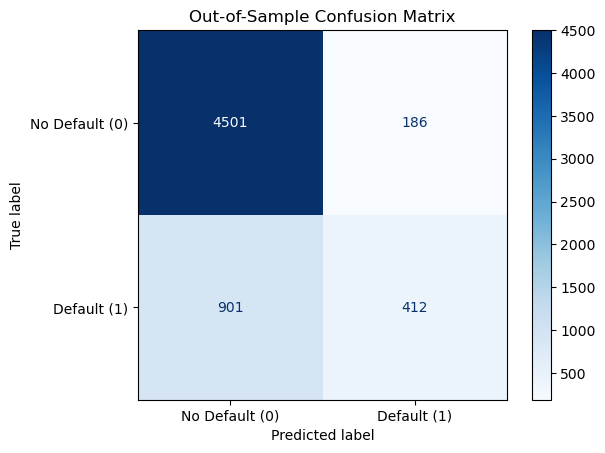

ROC analysis:


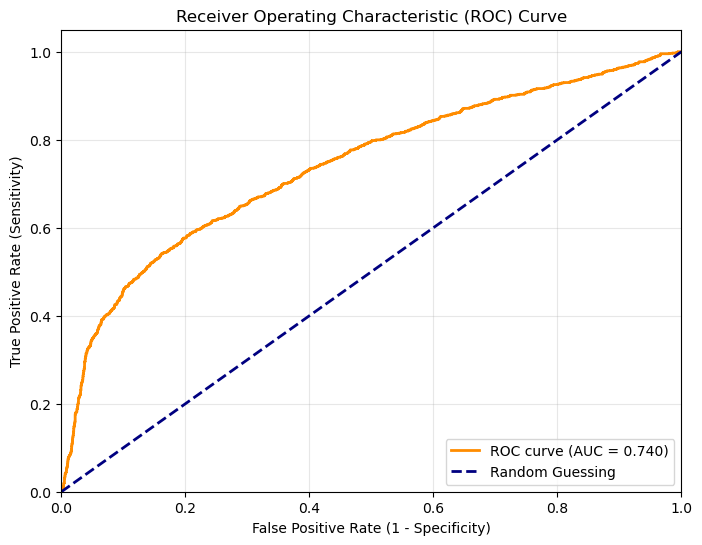

In [20]:
def evaluate_and_plot_model(X_test, Y_test, theta):
    """
    Computes predictions, displays the confusion matrix, and plots the ROC curve.
    """
    z_test = X_test @ theta
    p_test = sigmoid(z_test)
    
    predictions = (p_test >= 0.5).astype(int).to_numpy().flatten()
    actuals = Y_test.values.flatten()
    
    accuracy = np.mean(predictions == actuals)
    print(f"Out-of-Sample Accuracy: {accuracy * 100:.2f}%")

    print("Confusion matrix:")
    cm = confusion_matrix(actuals, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Out-of-Sample Confusion Matrix")
    plt.show()
    
    print("ROC analysis:")
    fpr, tpr, thresholds = roc_curve(actuals, p_test.to_numpy().flatten())
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

sensitivity_results_logit = evaluate_and_plot_model(X_test, Y_test, theta_tt)
sensitivity_results_logit

## 7. Feature Maps - Nonlinear Decision Boundaries

Feature maps work by applying deterministic transformations of varying degrees of polynomials to the features $\phi: \mathbb{R}^d \rightarrow \mathbb{R}^m$, constructing $m$ derived features from the original $d$ features with $z = \phi(x)$.

These deterministic transformations enable linear models to express nonlinear transformations in terms of the original inputs. One possible choice of transformation involves a quadratic transformation of all degree 2 terms to 3 of the features, that is with feature vector $\mathbf{x} \in \mathbb{R^m}$, where $m = 3$, a subset of the $d$ features, applying a transformation of $\phi(\mathbf{x}) = [1, x_1, x_2, x_3, x_1^2, x_2^2, x_3^2, x_1x_2, x_2x_3, x_1x_3]$ to these features. To avoid overfitting and the curse of dimensionality that arises from having to estimate many parameters when a high number of features is chosen, for this project a subset of three of the total features are used in the feature map. The chosen features in this project are bill_amt_mean, age and credit limit. 

The feature map transformation $\phi(\mathbf{x})$ can then be inputted into the sigmoid function to yield probabilities $ p = \sigma(\theta'\phi(x))$, When written out explicitly for any parameter values, the function yields a conic (quadratic) curve equation for the decision boundary that is nonlinear. The quadratic terms control curvature along axes, the linear terms control tilt and the interaction terms affect the rotation of the decision boundary. The nonlinearity in this decision boundary can often better partition the feature space between the predictions of default P($y=1|X)$ or not to default P($y=0|X$) compared to a linear decision boundary.

In [22]:
subset_features = credit_default[["AGE", "Credit Limit (NT Dollars)", "bill_amt_mean"]]
# Normalize the features as some are in vastly different units
normalized_features = (subset_features - subset_features.mean()) / subset_features.std()
x1 = normalized_features["AGE"]
x2 = normalized_features["Credit Limit (NT Dollars)"]
x3 = normalized_features["bill_amt_mean"]
x1square = x1**2
x2square = x2**2
x3square = x3**2
x1_x2 = x1 * x2
x2_x3 = x2 * x3
x1_x3 = x1 * x3

In [23]:
feature_dict = {
    "AGE": x1,
    "Credit Limit (NT Dollars)": x2,
    "bill_amt_mean": x3,
    "AGE^2": x1square,
    "Credit Limit^2": x2square,
    "bill_amt_mean^2": x3square,
    "AGE * Credit Limit": x1_x2,
    "Credit Limit * bill_amt_mean": x2_x3,
    "AGE * bill_amt_mean": x1_x3
}
# Construct design matrix for degree 2 feature map
X_fm = pd.DataFrame(feature_dict)
X_fm = sm.add_constant(X_fm)
n_fm = X_fm.shape[1]
theta_fm = np.zeros((n_fm, 1))
feature_map_d2 = fit_logistic_newton(X_fm, Y, max_iterations = 20, convergence_bound = 1e-6)
feature_map_d2

Converged in 6 iterations.


array([[-1.52605391],
       [ 0.11763646],
       [-0.68560346],
       [ 0.02759133],
       [-0.01715403],
       [ 0.14812156],
       [ 0.13277009],
       [ 0.08478723],
       [-0.24184162],
       [-0.07238364]])

In [24]:
summarize_coefficients(feature_map_d2, X_fm.columns)

,Feature,Coefficient (θ)
0,const,-1.526054e+00
1,AGE,1.176365e-01
2,Credit Limit (NT Dollars),-6.856035e-01
3,bill_amt_mean,2.759133e-02
4,AGE^2,-1.715403e-02
5,Credit Limit^2,1.481216e-01
6,bill_amt_mean^2,1.327701e-01
7,AGE * Credit Limit,8.478723e-02
8,Credit Limit * bill_amt_mean,-2.418416e-01
9,AGE * bill_amt_mean,-7.238364e-02


## 8. Classification trees

Classification trees work by recursively partitioning the feature space $\mathbb{R}^d$ into regions that are as pure as possible with respect to the class label. First, the classification tree algorithms work by placing all the training examples at a root node and then asking candidate questions to reduce the scope of possibilities as much possible, partitioning the feature space at each decision node. The algorithm continues contingent on whether pre-defined stopping criteria hold. 

These candidate questions are asked for each feature $x_j \in x$. For numerical data, in practice, such questions take the form of numerical thresholds e.g. $x_j \leq \tau$ (for instance, midpoints between sorted unique values). Impurity (reduction) measures measure how pure the individual classification regions are with respect to the class label. For each question, the node's data is then partitioned into left/right children nodes and an impurity reduction measure is computed as parent's impurity measure minus weighted child's node impurity (illustrated below). The decision tree then chooses the node with the largest impurity reduction. This process in then repeated for the following child nodes recursively until the stopping condition is met.

### 8.1 Impurity measures
At a node $t$, let $\mathcal{I_t}$ be the indices of training points that reach $t$ and let the empirical class proportions be:

$$p_{t,k} = \frac{\#\{i \in \mathcal{I}_t \mid y_i = k\}}{\#\{i \in \mathcal{I}_t\}}$$

$p_{t,k}$ labels the proportion of observations within $\mathcal{I}_t$ that are labelled class $k$. Let $\mathbf{p_t} = (p_{t,1}, p_{t,2}, ..., p_{t,k})$ be the empirical class distribution at node $t$. A subset of the data is pure or homogenous if it contains only a single class. If the dataset contains multiple classes, it is said to be impure.

An impurity measure, $Imp$ measures how impure the dataset is. A candidate split $s$ at each node divides $\mathcal{I}_t$ into child nodes $\mathcal{I}_L$ and $\mathcal{I}_R$, and then this $s$ is scored by the impurity decrease $$\Delta(s;t) = \text{Imp}(t) - \frac{\#\{i \in I_{L}\}}{\#\{i \in I_t\}} \text{Imp}(L) - \frac{\#\{i \in I_{R}\}}{\#\{i \in I_t\}} \text{Imp}(R)$$
The candidate split $s$ with the largest impurity decrease $\Delta$ is chosen. The tree grows greedily: at each node, it searches over the features or thresholds (in this case for numerical features) and picks the best candidate split, and this algorithm recurses until the stopping condition is met.

#### Deciding on an impurity measure Imp - Choices of impurity measure

#### 0. Misclassification rate
$$ Imp_M(t) = 1 - \max_{k} p_{t,k}$$
This is conceptually the simplest measure that directly measures misclassification error at each node. It suffers from serious issues however. When a candidate split occurs in which the majority class prediction is the same across both of the child nodes (i.e. majority of observations are positive (correct) in both child nodes), but some of the observations have still been sent in each direction of positive and negative (i.e. 100 split into 50-50 but with left child containing 50 positive and 0 negative and right child containing 30 positive and 20 negative for example) this yields the same weighted impurity for each child node and the misclassification rate shows no improvement whatsoever, despite the left child node clearly having greater predictive accuracy.
#### 1. Entropy measure (information impurity)
\begin{equation}
  \text{Imp}_H(t) = H(p_t) = -\sum_{k=1}^{K} p_{t,k} \log p_{t,k} \quad \text{with } 0 \log 0 := 0
\end{equation}

Entropy quantifies uncertainty in a distribution - this can be interpreted as the expected surprise of an outcome. The surprise of an outcome can be thought of as $-logp_{t,k}$ as the logarithmic form of this measure makes rare events (where $p_k$ is small) more surprising and the surprise of an certain event (where $p_k$ = 1) equal to 0. This measure achieves its maximum in a uniform distribution. In general, entropy is larger when the distribution is more spread out across different classes and smaller when one outcome dominates.

#### 2. Gini Impurity
$$ \text{Imp}_G(t) = 1 - \sum_{k=1}^{K} p_{t,k}^2 $$
Gini is the expected misclassification rate if you label at random from the class distribution $p_t$. It has a smooth form that is fast to compute.
Gini and Entropy measures of impurity typically yield similar results - the main difference is that Gini's behaviour due to its squared term is typically more quadratic whilst entropy is somewhat more sensitive to extremes in its logarithmic form.

### 8.2 Reducing overfitting in a classification tree
Unconstrained trees overfit on the training data - capturing noisy patterns in the training data rather than the underlying signal as the tree gets deeper, that is, without a form of either regularization or pruning technique to mitigate this issue. Classification trees as they get deeper carve out smaller noisy regions within the feature space that are extremely sensitive to variation in the training data. At the limit, an unconstrained tree would only classify every training point correctly if the true underlying data generating process was entirely captured by the training data, which is very unlikely in practice. 

One method available to deal with overfitting is using stopping conditions such as: minimum leaf (end of node) size, a maximum depth of tree, or minimum impurity decrease to stop splitting. In this project, the technique of pruning (illustrated below) is chosen instead.
 
#### Pruning
Pruning works by first growing a larger tree and then choosing smaller subtrees according to some criteria. One of the most commonly used criteria is minimizing the cost-complexity. Let $T_{max}$ represent a fully grown tree from which a smaller subtree will be selected and let $R(T)$ represent the empirical misclassification rate over the trees (sometimes called resubstitution error rate).

On its own, $R(T)$ is not a good measure for selecting a subtree as it will always favour bigger trees - this means a complexity penalty needs to be added. This complexity penalty balances out $R(T)$ as it favours smaller size trees. For any subtree $T$ $\preceq$ $T_{max}$, its complexity can be measured as the number of terminal tree nodes $|T|_{leaves}$. For a given $\alpha$ > 0 (cost complexity parameter), the cost-complexity measure is $$R_\alpha(T) = R(T) + \alpha|T|_{leaves}$$

Intuitively, trees with greater depth can partition the feature space into more smaller regions and are thus more likely to fit the training data more closely - the penalty term of $\alpha|T|_{leaves}$ affects how strongly such complexity is penalised.

Ultimately, the selected subtree depends on $\alpha$. If $\alpha$ = 0, then the largest tree $T_{max}$ minimizes $R_\alpha(T)$ as the penalty vanishes. As $\alpha \to \infty$, the penalty term dominates and the trivial tree with merely a single node is selected.

Formally, for any given $\alpha > 0$, the pruning optimization problem solution is given by $$T(\alpha) \in \arg\min_{T \preceq T_{\max}} R_\alpha(T), \quad \text{such that} \quad R_\alpha(T(\alpha)) = \min_{T \preceq T_{\max}} R_\alpha(T)$$

A minimizer is guaranteed to exist as there are always finitely many subtrees in $T_{max}$. Moreover, since the set of candidate subtrees is finite, this means the function mapping of $\alpha \mapsto T(\alpha)$ only changes at finitely many jump points; between these values of $\alpha$, the subtree remains optimal.

In [27]:
# Create train-test split before evaluating the pruned tree
X_tr, X_te, y_tr, y_te = train_test_split(X, default_outcome, test_size=0.2, random_state=42)

In [29]:
def evaluate_pruned_tree(criterion, cv=5):
    """
    X_tr: Training data design matrix
    X_te: Test data design matrix
    y_tr: Credit default (training data)
    y_te: Credit default (test data)
    cv : Number of folds used in cross validation
    Implements cost-complexity tree pruning via K-fold cross-validation.
    Performs hyperparameter selection for ccp_alpha exclusively on the training set via cross-validation.
    Reserves the untouched test set strictly for final model evaluation.
    """
    # Compute effective alpha path on training set with max depth limit
    clf_base = DecisionTreeClassifier(random_state=42, criterion=criterion, max_depth=15)
    path = clf_base.cost_complexity_pruning_path(X_tr, y_tr)
    
    ccp_alphas = path.ccp_alphas
    ccp_alphas = ccp_alphas[ccp_alphas >= 0]
    step = max(1, len(ccp_alphas) // 30)
    ccp_alphas = ccp_alphas[::step]
    
    # Compute mean ROC-AUC and Misclassification Rate via K-fold cross-validation on training data
    cv_aucs = []
    cv_errors = []
    
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, criterion=criterion, ccp_alpha=alpha, max_depth=15)
        
        auc_scores = cross_val_score(clf, X_tr, y_tr, cv=cv, scoring='roc_auc')
        cv_aucs.append(np.mean(auc_scores))
        
        acc_scores = cross_val_score(clf, X_tr, y_tr, cv=cv, scoring='accuracy')
        cv_errors.append(1 - np.mean(acc_scores))
        
    # Find optimal alphas under each cross-validation metric
    best_auc_idx = np.argmax(cv_aucs)
    best_err_idx = np.argmin(cv_errors)
    
    best_alpha_auc = ccp_alphas[best_auc_idx]
    best_alpha_err = ccp_alphas[best_err_idx] 
    
    # Refit optimal trees on full training set
    best_clf_auc = DecisionTreeClassifier(random_state=42, criterion=criterion, ccp_alpha=best_alpha_auc, max_depth=15)
    best_clf_auc.fit(X_tr, y_tr)
    
    best_clf_err = DecisionTreeClassifier(random_state=42, criterion=criterion, ccp_alpha=best_alpha_err, max_depth=15)
    best_clf_err.fit(X_tr, y_tr)
    
    # Evaluate final models once on holdout test set
    final_test_auc = roc_auc_score(y_te, best_clf_auc.predict_proba(X_te)[:, 1])
    final_test_err = 1 - accuracy_score(y_te, best_clf_err.predict(X_te))
    
    print(f"=== Criterion: {criterion.upper()} ===")
    print(f"Optimal Alpha (ROC-AUC): {best_alpha_auc:.6f} | True Test ROC-AUC: {final_test_auc:.6f}")
    print(f"Optimal Alpha (Min Error): {best_alpha_err:.6f} | True Test Error: {final_test_err:.6f}")
    
    return {
        "alphas": ccp_alphas,
        "cv_aucs": cv_aucs,
        "cv_errors": cv_errors,
        "best_alpha_auc": best_alpha_auc,
        "best_tree_auc": best_clf_auc,
        "test_auc": final_test_auc,
        "test_error": final_test_err
    }

# Execution calls
gini_results = evaluate_pruned_tree(criterion="gini", cv=5)
entropy_results = evaluate_pruned_tree(criterion="entropy", cv=5)

=== Criterion: GINI ===
Optimal Alpha (ROC-AUC): 0.000193 | True Test ROC-AUC: 0.751913
Optimal Alpha (Min Error): 0.000193 | True Test Error: 0.181333
=== Criterion: ENTROPY ===
Optimal Alpha (ROC-AUC): 0.000388 | True Test ROC-AUC: 0.753184
Optimal Alpha (Min Error): 0.000388 | True Test Error: 0.180500


### 9. Ensemble Method: Random Forest (Bagging + randomness in the features)
One effective way to deal with overfitting is that of ensemble methods. Ensemble methods in general work by training groups of base weaker learners (groups of two or more machine learning algorithms) to form a stronger prediction algorithm for a given classification task. This project uses random forests which combine the ensemble method of bagging (explained below) with randomness in the feature selection. 
#### Bagging (Bootstrap Aggregating)
Suppose a sample of the entire population ${Z = z}_{i=1}^{n}$ is taken. A bootstrap draws $n$ observations at random and with replacement from this sample $Z$. The method next involves computing a test statistic $\hat\theta = T(z)$ and its corresponding bootstrap replicates $\hat\theta_{(b)} = T(z_{(b))}$. The statistic $T$ could in theory be anything, but for purposes of this application the test statistic will be model parameters. Each test statistic $T$ can be thought of as a weak learner that can be aggregated to reduce overall variance. The validity of bootstrapping is predicated on the idea that the empirical distribution of the bootstrap replicates $\hat\theta_{(b)}$ approximates the true sampling distribution of $\hat\theta$.

More generally, the underlying idea behind ensemble methods is to train a diverse range of weak learners on a single classification task, including those with poor predictive ability (high bias). Among all of these weak learners, some will have outcome and error processes that exhibit high variance. An ensemble method then trains at least two high bias and two high variance weak learners to be combined into a better performing model for the classification task.

Unstable learners (such as decision trees) exhibit high variance - small perturbations in the dataset can change the fitted model substantially. Bootstrapping supplies systematic perturbations of the dataset. Given a classifier on the dataset's training data ${\mathbf{x}, y_i}_{i=1}^{n}$ with each $\mathbf{x^i} \in \mathbb{R}^n$ and $y^i \in {1,...,K}$,  draw a set of $B$ bootstrap samples $$\left\{Z_{(b)} = \left\{x_i^{(b)}, y_i^{(b)}\right\}_{i=1}^n\right\}_{b=1}^B$$

The model is then trained on each of these bootstrap samples,  producing a collection of predictors $\{h^{(b)}\}_{b=1}^B$. It is possible the predictors make both hard predictions $h^{b}: \mathbb{R}^n \rightarrow \set{1,...,K}$ and soft probabilistic predictions of $h(b): \mathbb{R}^n \rightarrow \set{Prob({1,...,K})}$. These predictors will be similar in accuracy but different in their idiosyncrasies - though averaging them with $$h_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^B h^{(b)}(x)$$ reduces variance approximately like an average of correlated estimates $$\text{Var}\left(h_{\text{bag}}(x)\right) \approx \sigma^2 \left( \rho + \frac{1 - \rho}{B} \right)$$ where $\sigma^2$ is the variance of a single model's prediction and $\rho$ is the pairwise correlation. The bootstrap step lowers $\rho$ by changing the training set - the averaging step then shrinks variance. This is the motivation behind the idea of bagging (bootstrap aggregating): use many bootstrap-trained models and aggregate them to stabilize parameters.

#### Random Forest
Random forests combine the ensemble method of bagging with randomness in the feature selection at each split in each of the decision trees. At every split, the tree considers a random subset of the total $d$ features (say $m_{try}$). This helps to reduce correlation across trees by preventing a small set of strong predictors from dominating every tree.

Random forests build $B$ decorrelated trees by combining bootstrap resampling with random feature subsetting at every single split in the decision tree. The algorithm works as follows:
1. **For each tree** $b = 1, \dots, B$:
   * **Bootstrap sample.** Draw $n$ examples with replacement from the training set to form $\mathcal{Z}^{(b)} = \left\{\mathbf{x}_i^{(b)}, y_i^{(b)}\right\}$.
   * **Grow a full tree.** Starting at the root, do the following recursively:
     * At the current node, sample without replacement a subset $\mathcal{S} \subset \{1, \dots, d\}$ of size $m_{\text{try}}$.
     * Find the best split only among $\mathcal{S}$, split, and recurse.
   * **Record OOB set.** The examples not sampled into $\mathcal{Z}^{(b)}$ are this tree's out-of-bag (OOB) cases.
2. **Aggregate predictions.**
   * **Classification:** Average per-class probabilities across trees and pick the $\arg\max$ (or majority vote).
   * **Regression:** Average the leaf means across trees.
3. **Out-of-bag estimation (useful technique).** For each training point $\mathbf{x}_i$, aggregate predictions across only those trees where $\mathbf{x}_i \notin \mathcal{Z}^{(b)}$ to estimate generalization error without a separate validation set.


In [31]:
# Random forest implementation of the algorithm explained above in text - chose to do through OOP here
class CustomRandomForest:
    # Label the different attributes of random forest algorithm using class attributes
    def __init__(self, n_estimators = 100, max_depth = 15, min_samples_split = 2, max_features = 'sqrt', random_state = 42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
    
    def fit(self, X, y):
        """This fit() function conducts the bootstrap sampling and the recursive random feature selection at each decision node that is involved with
        constructing a random forest algorithm."""
        X_arr = X.to_numpy() if isinstance(X, (pd.DataFrame, pd.Series)) else X
        y_arr = y.to_numpy().ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
        
        n_samples = X_arr.shape[0]
        rng = np.random.default_rng(self.random_state)
        
        self.trees = []
        self.oob_indices = []
        
        for _ in range(self.n_estimators):
            # 1. Bootstrap sampling with replacement
            boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
            oob_idx = np.setdiff1d(np.arange(n_samples), np.unique(boot_idx))
            
            # 2. Base Decision Tree with random feature subset selection (max_features)
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features,
                random_state=rng.integers(0, 1_000_000)
            )
            tree.fit(X_arr[boot_idx], y_arr[boot_idx])
            
            self.trees.append(tree)
            self.oob_indices.append(oob_idx)
            
        return self

    def predict_proba(self, X):
        X_arr = X.to_numpy() if isinstance(X, (pd.DataFrame, pd.Series)) else X
        # Collect probability predictions across all trees: shape (n_estimators, n_samples, n_classes)
        tree_probas = np.array([tree.predict_proba(X_arr) for tree in self.trees])
        # Average probabilities across the ensemble axis
        return np.mean(tree_probas, axis=0)

    def predict(self, X, threshold=0.5):
        probas = self.predict_proba(X)[:, 1]
        return (probas >= threshold).astype(int)

    def compute_oob_auc(self, X, y):
        X_arr = X.to_numpy() if isinstance(X, (pd.DataFrame, pd.Series)) else X
        y_arr = y.to_numpy().ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
        
        n_samples = X_arr.shape[0]
        oob_prob_sum = np.zeros(n_samples)
        oob_counts = np.zeros(n_samples)
        
        for tree, oob_idx in zip(self.trees, self.oob_indices):
            if len(oob_idx) > 0:
                preds = tree.predict_proba(X_arr[oob_idx])[:, 1]
                oob_prob_sum[oob_idx] += preds
                oob_counts[oob_idx] += 1
                
        # Evaluate only on samples that were OOB in at least one tree
        valid_mask = oob_counts > 0
        oob_avg_probs = oob_prob_sum[valid_mask] / oob_counts[valid_mask]
        
        return roc_auc_score(y_arr[valid_mask], oob_avg_probs)

In [32]:
# Fit custom ensemble using the CustomRandomForest object created through OOP
rf_custom = CustomRandomForest(n_estimators=100, max_depth=15, max_features='sqrt', random_state=42)
rf_custom.fit(X_train, Y_train)

# Extract probabilities and baseline metrics
oob_auc = rf_custom.compute_oob_auc(X_train, Y_train)
test_probs = rf_custom.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(Y_test, test_probs)

print(f"OOB ROC-AUC Score:  {oob_auc:.4f}")
print(f"Test ROC-AUC Score: {test_auc:.4f}")

# Perform threshold optimization (using Youden's J Statistic) to avoid arbitrary choice of 0.5
fpr, tpr, thresholds = roc_curve(Y_test, test_probs)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Decision Threshold: {optimal_threshold:.4f}")

OOB ROC-AUC Score:  0.7490
Test ROC-AUC Score: 0.7587
Optimal Decision Threshold: 0.2539
